In [5]:
import tensorflow as tf
print(tf.__version__)


2.20.0


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ========= PATHS =========
BASE_DIR = r"C:\Users\user\Desktop\Skin Detector\archive"
DATASET_DIR = os.path.join(BASE_DIR, "dataset")            # your dataset folder
SPLIT_DIR   = os.path.join(BASE_DIR, "dataset_split")      # will be created
MODELS_DIR  = os.path.join(BASE_DIR, "models")             # model save here

os.makedirs(SPLIT_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print("BASE_DIR  :", BASE_DIR)
print("DATASET   :", DATASET_DIR)
print("SPLIT_DIR :", SPLIT_DIR)
print("MODELS_DIR:", MODELS_DIR)

print("\nDataset folder exists? ", os.path.exists(DATASET_DIR))
print("Split folder exists?    ", os.path.exists(SPLIT_DIR))
print("Models folder exists?   ", os.path.exists(MODELS_DIR))


BASE_DIR  : C:\Users\user\Desktop\Skin Detector\archive
DATASET   : C:\Users\user\Desktop\Skin Detector\archive\dataset
SPLIT_DIR : C:\Users\user\Desktop\Skin Detector\archive\dataset_split
MODELS_DIR: C:\Users\user\Desktop\Skin Detector\archive\models

Dataset folder exists?  True
Split folder exists?     True
Models folder exists?    True


In [7]:
classes = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
print("Total folders (classes) found:", len(classes))
print("Classes:", classes)


Total folders (classes) found: 3
Classes: ['test', 'train', 'val']


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

IMG_SIZE = 224
BATCH = 16

SPLIT_DIR = r"C:\Users\user\Desktop\Skin Detector\archive\dataset"

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    os.path.join(SPLIT_DIR, "train"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    class_mode="categorical"
)

val_data = val_test_gen.flow_from_directory(
    os.path.join(SPLIT_DIR, "val"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    class_mode="categorical"
)

test_data = val_test_gen.flow_from_directory(
    os.path.join(SPLIT_DIR, "test"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    class_mode="categorical",
    shuffle=False
)


Found 1161 images belonging to 6 classes.
Found 330 images belonging to 6 classes.
Found 338 images belonging to 6 classes.


In [9]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

NUM_CLASSES = train_data.num_classes
print("NUM_CLASSES =", NUM_CLASSES)

base = MobileNetV2(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = False  # start with frozen base

x = GlobalAveragePooling2D()(base.output)
x = Dropout(0.3)(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


NUM_CLASSES = 6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
import os
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# ===============================
# Model save directory
# ===============================
MODEL_DIR = r"C:\Users\user\Desktop\Skin Detector\archive\models"
os.makedirs(MODEL_DIR, exist_ok=True)

# ===============================
# Callbacks
# ===============================

# 1. Save BEST model in KERAS format (.keras)
checkpoint = ModelCheckpoint(
    filepath=os.path.join(MODEL_DIR, "skin_detector_best_7cls.keras"),
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# 2. Early stopping (overfitting protection)
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 3. Reduce learning rate if model stuck
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# ===============================
# Train model
# ===============================
EPOCHS = 25

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop, reduce_lr]
)


Epoch 1/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7271 - loss: 0.7183  
Epoch 1: val_accuracy improved from None to 0.77576, saving model to C:\Users\user\Desktop\Skin Detector\archive\models\skin_detector_best_7cls.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.7416 - loss: 0.6826 - val_accuracy: 0.7758 - val_loss: 0.6239 - learning_rate: 9.0000e-06
Epoch 2/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7419 - loss: 0.7017  
Epoch 2: val_accuracy improved from 0.77576 to 0.77879, saving model to C:\Users\user\Desktop\Skin Detector\archive\models\skin_detector_best_7cls.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.7399 - loss: 0.6856 - val_accuracy: 0.7788 - val_loss: 0.6255 - learning_rate: 9.0000e-06
Epoch 3/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7304 - loss: 0.6791  
Epoch 3: val_accuracy did not improve from 0.77879
73/73 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.7347 - loss: 0.6861 - val_accuracy: 0.7758 - val_

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate on test data
test_loss, test_acc = model.evaluate(test_data)
print(f"\n✅ Test Accuracy: {test_acc*100:.2f}%")

# Predictions
y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_data.classes

# Class names
class_names = list(test_data.class_indices.keys())

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
import os

BASE_DIR = r"C:\Users\user\Desktop\Skin Detector\archive\dataset"

diseases = ["Acne", "Eczema", "Psoriasis"]

def count_images(folder_path):
    if not os.path.exists(folder_path):
        return 0
    return len([
        f for f in os.listdir(folder_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

print("📊 DATASET IMAGE COUNT (Train / Val / Test)\n")

for disease in diseases:
    train_path = os.path.join(BASE_DIR, "train", disease)
    val_path   = os.path.join(BASE_DIR, "val", disease)
    test_path  = os.path.join(BASE_DIR, "test", disease)

    train_count = count_images(train_path)
    val_count   = count_images(val_path)
    test_count  = count_images(test_path)

    total = train_count + val_count + test_count

    print(f"🦠 {disease}")
    print(f"  Train: {train_count}")
    print(f"  Val  : {val_count}")
    print(f"  Test : {test_count}")
    print(f"  Total: {total}")
    print("-" * 35)


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers


In [ ]:
# Dataset paths
BASE_DIR = r"C:\Users\user\Desktop\Skin Detector\archive\dataset"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")

# Image & training settings
IMG_SIZE = 224
BATCH = 16
NUM_CLASSES = 7


In [ ]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.25,
    shear_range=0.2,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True
)

val_test_gen = ImageDataGenerator(rescale=1./255)


In [ ]:
train_data = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    class_mode="categorical"
)

val_data = val_test_gen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    class_mode="categorical"
)

test_data = val_test_gen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    class_mode="categorical",
    shuffle=False
)


In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  # freeze backbone

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

MODEL_DIR = r"C:\Users\user\Desktop\Skin Detector\archive\models"
os.makedirs(MODEL_DIR, exist_ok=True)

checkpoint = ModelCheckpoint(
    os.path.join(MODEL_DIR, "skin_detector_v2_aug.keras"),
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=[checkpoint, early_stop, reduce_lr]
)


In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.legend()
plt.title("Loss")

plt.show()


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_true = test_data.classes
y_pred = np.argmax(model.predict(test_data), axis=1)

print(classification_report(y_true, y_pred, target_names=train_data.class_indices.keys()))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=train_data.class_indices.keys(),
            yticklabels=train_data.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
# Unfreeze top layers of base model
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
history_ft = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[checkpoint, early_stop, reduce_lr],
    class_weight=class_weights
)


In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Get class indices from training generator
class_indices = train_data.class_indices
print("Class indices:", class_indices)

# Get labels
y_train = train_data.classes

# Compute class weights
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

# Convert to dictionary
class_weights = dict(enumerate(weights))

print("Class weights:", class_weights)


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
history_ft = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[checkpoint, early_stop, reduce_lr],
    class_weight=class_weights
)


In [ ]:
import tensorflow as tf

MODEL_PATH = r"C:\Users\user\Desktop\Skin Detector\archive\models\skin_detector_best_7cls.keras"

best_model = tf.keras.models.load_model(MODEL_PATH)

test_loss, test_acc = best_model.evaluate(test_data)
print("Test Accuracy:", test_acc)


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# True labels
y_true = test_data.classes

# Model predictions
y_pred_probs = best_model.predict(test_data)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = list(test_data.class_indices.keys())

print("📊 CLASSIFICATION REPORT\n")
print(classification_report(y_true, y_pred, target_names=class_names))


In [ ]:
# STEP 10: Save final trained model

FINAL_MODEL_PATH = r"C:\Users\user\Desktop\Skin Detector\archive\models\skin_detector_final.keras"

model.save(FINAL_MODEL_PATH)

print("✅ Model successfully saved at:")
print(FINAL_MODEL_PATH)


In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load trained model
MODEL_PATH = r"C:\Users\user\Desktop\Skin Detector\archive\models\skin_detector_final.keras"
model = tf.keras.models.load_model(MODEL_PATH)

# Class names (same order as training)
class_names = [
    "Acne",
    "Eczema",
    "Normal",
    "Psoriasis",
    "Rosacea",
    "Vitiligo",
    "Warts"
]


In [ ]:
# Image path (change this)
IMG_PATH = r"C:\Users\user\Downloads\WhatsApp Image 2025-12-13 at 2.53.27 PM.jpeg"

IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize & normalize
img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)


In [ ]:
pred = model.predict(img_array)
predicted_class = class_names[np.argmax(pred)]
confidence = np.max(pred) * 100

plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)")
plt.show()

print("🩺 Predicted Disease:", predicted_class)
print("📊 Confidence:", round(confidence, 2), "%")


In [ ]:
# Image path (change this)
IMG_PATH = r"C:\Users\user\Downloads\WhatsApp Image 2025-12-13 at 10.38.13 PM.jpeg"

IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize & normalize
img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)


In [ ]:
pred = model.predict(img_array)
predicted_class = class_names[np.argmax(pred)]
confidence = np.max(pred) * 100

plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)")
plt.show()

print("🩺 Predicted Disease:", predicted_class)
print("📊 Confidence:", round(confidence, 2), "%")

In [ ]:
# Image path (change this)
IMG_PATH = r"C:\Users\user\Downloads\WhatsApp Image 2025-12-13 at 11.03.21 PM.jpeg"

IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize & normalize
img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [ ]:
pred = model.predict(img_array)
predicted_class = class_names[np.argmax(pred)]
confidence = np.max(pred) * 100

plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)")
plt.show()

print("🩺 Predicted Disease:", predicted_class)
print("📊 Confidence:", round(confidence, 2), "%")

In [ ]:
# ===============================
# STEP B: Image Upload & Prediction (REPEAT THIS)
# ===============================

IMG_PATH = r"C:\Users\user\Downloads\WhatsApp Image 2025-12-13 at 11.03.21 PM.jpeg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)
predicted_index = np.argmax(pred)
confidence = pred[0][predicted_index] * 100
predicted_class = class_names[predicted_index]

# Show Image + Prediction
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.show()

# Print details
print("🧬 Predicted Disease:", predicted_class)
print(f"📊 Confidence: {confidence:.2f} %")

print("\n💊 Recommended Creams / Treatment:")
for cream in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", cream)


In [ ]:
# ===============================
# STEP B: Image Upload & Prediction (REPEAT THIS)
# ===============================

IMG_PATH = r"C:\Users\user\Downloads\WhatsApp Image 2025-12-13 at 2.53.27 PM.jpeg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)
predicted_index = np.argmax(pred)
confidence = pred[0][predicted_index] * 100
predicted_class = class_names[predicted_index]

# Show Image + Prediction
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.show()

# Print details
print("🧬 Predicted Disease:", predicted_class)
print(f"📊 Confidence: {confidence:.2f} %")

print("\n💊 Recommended Creams / Treatment:")
for cream in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", cream)


In [16]:
import tensorflow as tf
import numpy as np
from PIL import Image
import io

from ipywidgets import FileUpload, Button, VBox, Output
from IPython.display import display


In [ ]:
model = tf.keras.models.load_model(
    r"C:\Users\user\Desktop\Skin Detector\archive\models\skin_detector_final.keras"
)

class_names = [
    "Acne","Eczema","Normal","Psoriasis",
    "Rosacea","Vitiligo","Warts"
]

recommendations = {
    "Acne": ["Benzoyl Peroxide", "Salicylic Acid"],
    "Eczema": ["Hydrocortisone Cream", "Moisturizer"],
    "Psoriasis": ["Coal Tar", "Vitamin D Cream"],
    "Rosacea": ["Metronidazole", "Azelaic Acid"],
    "Vitiligo": ["Topical Steroids", "Phototherapy"],
    "Warts": ["Salicylic Acid", "Cryotherapy"],
    "Normal": ["No treatment required"]
}


In [ ]:
upload = FileUpload(accept='image/*', multiple=False)
btn = Button(description="Predict", button_style="success")
out = Output()


In [ ]:
def predict_image(b):
    out.clear_output()

    if len(upload.value) == 0:
        with out:
            print("⚠ Please upload an image first")
        return

    image_bytes = list(upload.value.values())[0]['content']
    img = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    img_resized = img.resize((224,224))

    img_arr = np.array(img_resized) / 255.0
    img_arr = np.expand_dims(img_arr, axis=0)

    preds = model.predict(img_arr)[0]
    idx = np.argmax(preds)
    confidence = preds[idx] * 100
    disease = class_names[idx]

    with out:
        display(img)
        print("🩺 Disease:", disease)
        print("📊 Confidence:", round(confidence,2), "%")
        print("\n💊 Recommended Creams:")
        for c in recommendations.get(disease, ["Consult Dermatologist"]):
            print("•", c)
        print("\n⚠ This is not a medical diagnosis.")


In [ ]:
btn.on_click(predict_image)


In [ ]:
VBox([upload, btn, out])


In [ ]:
IMG_PATH = r"C:\Users\user\Downloads\WhatsApp Image 2025-12-13 at 10.38.13 PM.jpeg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)
predicted_index = np.argmax(pred)
confidence = pred[0][predicted_index] * 100
predicted_class = class_names[predicted_index]

# Show Image + Prediction
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.show()

# Print details
print("🧬 Predicted Disease:", predicted_class)
print(f"📊 Confidence: {confidence:.2f} %")
print("\n💊 Recommended Creams / Treatment:")
for cream in recommendations.get(predicted_class, ["Consult Dermatologist"]):
 print("•", cream)

In [ ]:
IMG_PATH = r"C:\Users\user\Downloads\WhatsApp Image 2025-12-13 at 11.03.21 PM.jpeg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)
predicted_index = np.argmax(pred)
confidence = pred[0][predicted_index] * 100
predicted_class = class_names[predicted_index]

# Show Image + Prediction
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.show()

# Print details
print("🧬 Predicted Disease:", predicted_class)
print(f"📊 Confidence: {confidence:.2f} %")
print("\n💊 Recommended Creams / Treatment:")
for cream in recommendations.get(predicted_class, ["Consult Dermatologist"]):
 print("•", cream)

In [ ]:
IMG_PATH = r"C:\Users\user\Downloads\WhatsApp Image 2025-12-13 at 2.53.27 PM.jpeg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)
predicted_index = np.argmax(pred)
confidence = pred[0][predicted_index] * 100
predicted_class = class_names[predicted_index]

# Show Image + Prediction
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.show()

# Print details
print("🧬 Predicted Disease:", predicted_class)
print(f"📊 Confidence: {confidence:.2f} %")
print("\n💊 Recommended Creams / Treatment:")
for cream in recommendations.get(predicted_class, ["Consult Dermatologist"]):
 print("•", cream)

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt


In [ ]:
MODEL_PATH = r"C:\Users\user\Desktop\Skin Detector\archive\models\skin_detector_final.keras"

model = tf.keras.models.load_model(MODEL_PATH)

print("✅ Model loaded")


In [ ]:
class_names = [
    "Acne",
    "Eczema",
    "Normal",
    "Psoriasis",
    "Rosacea",
    "Vitiligo",
    "Warts"
]


In [ ]:
recommendations = {
    "Acne": [
        "Benzoyl Peroxide 2.5%",
        "Salicylic Acid Cleanser",
        "Adapalene Gel"
    ],
    "Eczema": [
        "Hydrocortisone Cream",
        "Moisturizers (CeraVe, Cetaphil)",
        "Avoid hot showers"
    ],
    "Normal": [
        "No treatment required",
        "Use sunscreen daily"
    ],
    "Psoriasis": [
        "Coal Tar Cream",
        "Vitamin D analogues",
        "Consult dermatologist"
    ],
    "Rosacea": [
        "Metronidazole Gel",
        "Azelaic Acid",
        "Avoid triggers"
    ],
    "Vitiligo": [
        "Topical Corticosteroids",
        "Phototherapy",
        "Consult dermatologist"
    ],
    "Warts": [
        "Salicylic Acid",
        "Cryotherapy",
        "Consult dermatologist"
    ]
}


In [ ]:
IMG_PATH = r"C:\Users\user\Downloads\1800ss_getty_rf_scratching_arm.webp"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)
idx = np.argmax(pred)
confidence = pred[0][idx] * 100
predicted_class = class_names[idx]

# Show output
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.show()

print("🧬 Predicted Disease:", predicted_class)
print(f"📊 Confidence: {confidence:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


In [ ]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\eczema\1.jpeg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)
idx = np.argmax(pred)
confidence = pred[0][idx] * 100
predicted_class = class_names[idx]

# Show output
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.show()

print("🧬 Predicted Disease:", predicted_class)
print(f"📊 Confidence: {confidence:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


In [ ]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\eczema\2.webp"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)
idx = np.argmax(pred)
confidence = pred[0][idx] * 100
predicted_class = class_names[idx]

# Show output
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.show()

print("🧬 Predicted Disease:", predicted_class)
print(f"📊 Confidence: {confidence:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


In [ ]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\eczema\4.jpg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


In [ ]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\eczema\5.jpeg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


In [ ]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Acne\1.jpg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


In [ ]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Acne\2.png"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


In [ ]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Acne\3.jpg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


In [ ]:
import streamlit as st
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import InputLayer

# ================= PAGE CONFIG =================
st.set_page_config(
    page_title="Skin Disease Detector",
    page_icon="🩺",
    layout="wide"
)


# ================= THEME SELECT (MOON / SUN STYLE) =================
if "theme" not in st.session_state:
    st.session_state.theme = "Dark Mode"

theme_label = "Dark Mode" if st.session_state.theme == "Dark Mode" else "Light Mode"

st.sidebar.markdown(
    """
    <div class="sidebar-logo">
        <div class="sidebar-logo-icon">🩺</div>
        <div class="sidebar-logo-text">
            <span class="sidebar-logo-title">DermaScan AI</span>
            <span class="sidebar-logo-sub">Skin Diagnosis Assistant</span>
        </div>
    </div>
    """,
    unsafe_allow_html=True
)

st.sidebar.markdown(
    "<h3 style='text-align:center;'>Appearance</h3>",
    unsafe_allow_html=True
)

theme = st.sidebar.radio(
    "",
    ["Dark Mode", "Light Mode"],
    index=0 if st.session_state.theme == "Dark Mode" else 1
)

st.session_state.theme = theme

st.sidebar.markdown("<hr class='sidebar-divider'/>", unsafe_allow_html=True)

st.sidebar.markdown(
    """
    <div class="sidebar-info">
        <p class="sidebar-info-title">How it works</p>
        <ol class="sidebar-info-list">
            <li>Upload a clear photo of the affected skin area</li>
            <li>The AI model analyzes the image</li>
            <li>Get the predicted condition, symptoms & care tips</li>
        </ol>
        <p class="sidebar-info-title">Detects</p>
        <div class="sidebar-tags">
            <span class="tag">Acne</span>
            <span class="tag">Eczema</span>
            <span class="tag">Psoriasis</span>
            <span class="tag">Rosacea</span>
            <span class="tag">Scabies</span>
            <span class="tag">Vitiligo</span>
            <span class="tag">Warts</span>
        </div>
    </div>
    """,
    unsafe_allow_html=True
)


if theme == "Dark Mode":
    BG = "#0b0f19"
    BG_GRADIENT = "radial-gradient(circle at 15% 10%, rgba(56,189,248,0.16), transparent 40%), radial-gradient(circle at 85% 20%, rgba(168,85,247,0.14), transparent 45%), radial-gradient(circle at 50% 100%, rgba(34,211,238,0.10), transparent 50%), #0b0f19"
    CARD = "linear-gradient(145deg, rgba(15,23,42,0.85), rgba(30,41,59,0.85))"
    CARD_BORDER = "rgba(148,163,184,0.15)"
    TEXT = "#e5e7eb"
    SUBTEXT = "#94a3b8"
    TITLE = "#60a5fa"
    ACCENT = "#22d3ee"
    ACCENT2 = "#a855f7"
    GLOW = "rgba(56,189,248,0.35)"
    GAUGE_TRACK = "rgba(148,163,184,0.15)"
else:
    BG = "#f4f7fb"
    BG_GRADIENT = "radial-gradient(circle at 15% 10%, rgba(37,99,235,0.08), transparent 40%), radial-gradient(circle at 85% 20%, rgba(168,85,247,0.07), transparent 45%), #f4f7fb"
    CARD = "linear-gradient(145deg, #ffffff, #f8fafc)"
    CARD_BORDER = "rgba(15,23,42,0.08)"
    TEXT = "#0f172a"
    SUBTEXT = "#475569"
    TITLE = "#1e3a8a"
    ACCENT = "#0ea5e9"
    ACCENT2 = "#7c3aed"
    GLOW = "rgba(37,99,235,0.18)"
    GAUGE_TRACK = "rgba(15,23,42,0.08)"

# ================= FULL PAGE CSS =================
st.markdown(f"""
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;500;600;700;800&family=Inter:wght@400;500;600&display=swap');
@property --p {{
  syntax: '<number>';
  inherits: true;
  initial-value: 0;
}}

* {{
    font-family: 'Inter', 'Poppins', sans-serif;
}}

html, body, .stApp {{
    background: {BG_GRADIENT} !important;
    color: {TEXT} !important;
    background-attachment: fixed !important;
}}

header, section.main > div {{
    background: transparent !important;
}}

#MainMenu {{visibility: hidden;}}
footer {{visibility: hidden;}}

::-webkit-scrollbar {{ width: 10px; }}
::-webkit-scrollbar-track {{ background: transparent; }}
::-webkit-scrollbar-thumb {{ background: {ACCENT}; border-radius: 10px; opacity: 0.6; }}

label {{
    color: {TEXT} !important;
    font-weight: 600;
}}

/* ============ ANIMATIONS ============ */
@keyframes fadeSlideUp {{
    from {{ opacity: 0; transform: translateY(24px); }}
    to {{ opacity: 1; transform: translateY(0); }}
}}
@keyframes fadeIn {{
    from {{ opacity: 0; }}
    to {{ opacity: 1; }}
}}
@keyframes floatUpDown {{
    0%, 100% {{ transform: translateY(0px); }}
    50% {{ transform: translateY(-8px); }}
}}
@keyframes pulseGlow {{
    0%, 100% {{ box-shadow: 0 0 18px {GLOW}; }}
    50% {{ box-shadow: 0 0 34px {GLOW}; }}
}}
@keyframes shimmer {{
    0% {{ background-position: -300px 0; }}
    100% {{ background-position: 300px 0; }}
}}
@keyframes growBar {{
    from {{ transform: scaleX(0); }}
    to {{ transform: scaleX(1); }}
}}
@keyframes popIn {{
    0% {{ opacity: 0; transform: scale(0.85); }}
    100% {{ opacity: 1; transform: scale(1); }}
}}

/* ============ HERO ============ */
.hero-wrap {{
    text-align: center;
    padding: 18px 0 8px 0;
    animation: fadeSlideUp 0.8s ease-out both;
}}
.hero-badge {{
    display: inline-block;
    padding: 6px 18px;
    border-radius: 999px;
    background: linear-gradient(90deg, {ACCENT}22, {ACCENT2}22);
    border: 1px solid {ACCENT}55;
    color: {ACCENT};
    font-size: 13px;
    font-weight: 600;
    letter-spacing: 0.5px;
    margin-bottom: 14px;
    animation: floatUpDown 3.5s ease-in-out infinite;
}}
h1.app-title {{
    font-family: 'Poppins', sans-serif !important;
    background: linear-gradient(90deg, {TITLE}, {ACCENT2});
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    background-clip: text;
    text-align: center;
    font-size: 46px;
    font-weight: 800;
    margin-bottom: 6px;
    letter-spacing: -0.5px;
}}
p.app-subtitle {{
    text-align: center;
    color: {SUBTEXT};
    font-size: 17px;
    font-weight: 500;
    margin-bottom: 4px;
}}

h2 {{
    font-family: 'Poppins', sans-serif !important;
    color: {TITLE} !important;
    text-align: center;
    font-weight: 700 !important;
    margin-top: 8px !important;
}}

/* ============ FILE UPLOADER ============ */
div[data-testid="stFileUploader"] {{
    background: {CARD} !important;
    border: 2px dashed {ACCENT}66 !important;
    border-radius: 22px !important;
    padding: 22px !important;
    box-shadow: 0 8px 30px {GLOW};
    transition: all 0.35s ease;
    animation: fadeSlideUp 0.9s ease-out both;
}}
div[data-testid="stFileUploader"]:hover {{
    border-color: {ACCENT} !important;
    transform: translateY(-3px);
    box-shadow: 0 12px 40px {GLOW};
}}
div[data-testid="stFileUploaderDropzone"] {{
    background: transparent !important;
}}
div[data-testid="stFileUploaderDropzoneInstructions"] {{
    color: {TEXT} !important;
}}
div[data-testid="stFileUploaderDropzoneInstructions"] span,
div[data-testid="stFileUploaderDropzoneInstructions"] small,
div[data-testid="stFileUploaderDropzoneInstructions"] div {{
    color: {TEXT} !important;
    opacity: 1 !important;
}}
div[data-testid="stFileUploaderDropzoneInstructions"] small {{
    color: {SUBTEXT} !important;
}}
div[data-testid="stFileUploaderDropzoneInstructions"] svg {{
    fill: {ACCENT} !important;
}}
div[data-testid="stFileUploader"] section {{
    background: transparent !important;
}}
div[data-testid="stFileUploader"] button {{
    background: linear-gradient(90deg, {ACCENT}, {ACCENT2}) !important;
    color: #ffffff !important;
    border: none !important;
    border-radius: 10px !important;
    font-weight: 600 !important;
    padding: 8px 18px !important;
    transition: transform 0.25s ease, box-shadow 0.25s ease;
}}
div[data-testid="stFileUploader"] button:hover {{
    transform: translateY(-2px);
    box-shadow: 0 6px 18px {GLOW};
}}
div[data-testid="stFileUploader"] button p {{
    color: #ffffff !important;
}}

/* ============ UPLOADED IMAGE ============ */
div[data-testid="stImage"] {{
    animation: popIn 0.6s ease-out both;
}}
div[data-testid="stImage"] img {{
    border-radius: 20px !important;
    box-shadow: 0 10px 34px {GLOW};
    border: 1px solid {CARD_BORDER};
}}

/* ============ GENERIC CARD ============ */
.section-card {{
    background: {CARD};
    border: 1px solid {CARD_BORDER};
    border-radius: 22px;
    padding: 26px 30px;
    margin: 18px auto;
    box-shadow: 0 10px 30px rgba(0,0,0,0.12);
    animation: fadeSlideUp 0.7s ease-out both;
    transition: transform 0.3s ease, box-shadow 0.3s ease;
}}
.section-card:hover {{
    transform: translateY(-4px);
    box-shadow: 0 16px 40px {GLOW};
}}

/* ============ RESULT / GAUGE ============ */
.result-box {{
    background: {CARD};
    border: 1px solid {CARD_BORDER};
    padding: 36px 24px;
    border-radius: 26px;
    margin-top: 24px;
    box-shadow: 0 12px 40px {GLOW};
    text-align: center;
    animation: fadeSlideUp 0.8s ease-out both, pulseGlow 4s ease-in-out infinite 1s;
}}
.result-eyebrow {{
    font-family: 'Poppins', sans-serif;
    font-size: 13px;
    font-weight: 700;
    letter-spacing: 2px;
    text-transform: uppercase;
    color: {ACCENT};
    margin: 0 0 6px 0;
}}
.disease {{
    font-family: 'Poppins', sans-serif;
    font-size: 40px;
    font-weight: 800;
    background: linear-gradient(90deg, {ACCENT}, {ACCENT2});
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    background-clip: text;
    margin-top: 4px;
}}

.gauge-outer {{
    --p: 0;
    width: 176px;
    height: 176px;
    border-radius: 50%;
    margin: 18px auto 8px auto;
    display: flex;
    align-items: center;
    justify-content: center;
    position: relative;
    background: conic-gradient(from -90deg, {ACCENT} calc(var(--p) * 3.6deg), {GAUGE_TRACK} 0deg);
    animation: fillGauge 1.6s cubic-bezier(0.22, 1, 0.36, 1) forwards;
    box-shadow: 0 0 30px {GLOW};
}}
@keyframes fillGauge {{
    to {{ --p: var(--target); }}
}}
.gauge-inner {{
    width: 138px;
    height: 138px;
    border-radius: 50%;
    background: {BG};
    display: flex;
    flex-direction: column;
    align-items: center;
    justify-content: center;
    box-shadow: inset 0 0 12px rgba(0,0,0,0.15);
}}
.gauge-value {{
    font-size: 30px;
    font-weight: 800;
    font-family: 'Poppins', sans-serif;
    color: {TEXT};
}}
.gauge-label {{
    font-size: 12px;
    color: {SUBTEXT};
    letter-spacing: 1px;
    text-transform: uppercase;
    margin-top: 2px;
}}

/* ============ CONFIDENCE BAR (fallback / secondary) ============ */
.confidence-track {{
    width: 80%;
    max-width: 420px;
    height: 10px;
    background: {GAUGE_TRACK};
    border-radius: 999px;
    margin: 14px auto 0 auto;
    overflow: hidden;
}}
.confidence-fill {{
    height: 100%;
    border-radius: 999px;
    background: linear-gradient(90deg, {ACCENT}, {ACCENT2});
    transform-origin: left;
    animation: growBar 1.4s cubic-bezier(0.22, 1, 0.36, 1) both;
}}

/* ============ DESCRIPTION ============ */
.description-box {{
    background: {CARD};
    border: 1px solid {CARD_BORDER};
    padding: 24px 30px;
    margin: 16px auto;
    max-width: 780px;
    border-radius: 20px;
    color: {TEXT};
    text-align: center;
    line-height: 1.7;
    box-shadow: 0 8px 26px rgba(0,0,0,0.10);
    font-size: 16px;
    animation: fadeSlideUp 0.7s ease-out both;
}}

/* ============ SYMPTOMS GRID ============ */
.symptom-grid {{
    display: grid;
    grid-template-columns: repeat(auto-fit, minmax(230px, 1fr));
    gap: 14px;
    max-width: 900px;
    margin: 16px auto;
}}
.symptom-chip {{
    background: {CARD};
    border: 1px solid {CARD_BORDER};
    border-left: 4px solid {ACCENT};
    border-radius: 14px;
    padding: 14px 16px;
    text-align: left;
    font-size: 14.5px;
    color: {TEXT};
    box-shadow: 0 6px 18px rgba(0,0,0,0.08);
    transition: transform 0.25s ease, box-shadow 0.25s ease;
    animation: fadeSlideUp 0.6s ease-out both;
}}
.symptom-chip:hover {{
    transform: translateY(-3px) scale(1.015);
    box-shadow: 0 10px 26px {GLOW};
    border-left-color: {ACCENT2};
}}
.symptom-check {{
    display: inline-flex;
    align-items: center;
    justify-content: center;
    width: 18px;
    height: 18px;
    margin-right: 10px;
    border-radius: 5px;
    background: {ACCENT}22;
    color: {ACCENT};
    font-size: 11px;
    font-weight: 700;
}}

/* ============ TREATMENT GRID ============ */
.treatment-grid {{
    display: grid;
    grid-template-columns: repeat(auto-fit, minmax(260px, 1fr));
    gap: 16px;
    max-width: 1000px;
    margin: 16px auto;
}}
.treatment-box {{
    background: {CARD};
    border: 1px solid {CARD_BORDER};
    padding: 18px 18px;
    border-radius: 16px;
    color: {TEXT};
    text-align: left;
    box-shadow: 0 8px 22px rgba(34,197,94,0.12);
    display: flex;
    gap: 12px;
    align-items: flex-start;
    transition: transform 0.25s ease, box-shadow 0.25s ease;
    animation: fadeSlideUp 0.65s ease-out both;
    font-size: 14.5px;
    line-height: 1.5;
}}
.treatment-box:hover {{
    transform: translateY(-4px);
    box-shadow: 0 14px 32px rgba(34,197,94,0.25);
}}
.treatment-num {{
    flex-shrink: 0;
    width: 30px;
    height: 30px;
    border-radius: 50%;
    background: linear-gradient(135deg, {ACCENT}, #22c55e);
    color: #fff;
    display: flex;
    align-items: center;
    justify-content: center;
    font-weight: 700;
    font-size: 13px;
}}

/* ============ CHART CARD ============ */
.chart-card {{
    background: {CARD};
    border: 1px solid {CARD_BORDER};
    border-radius: 22px;
    padding: 12px 18px 4px 18px;
    max-width: 780px;
    margin: 16px auto;
    box-shadow: 0 10px 30px rgba(0,0,0,0.10);
    animation: fadeSlideUp 0.7s ease-out both;
}}

/* ============ FOOTER DISCLAIMER ============ */
.disclaimer-box {{
    max-width: 620px;
    margin: 30px auto 12px auto;
    padding: 14px 20px;
    border-radius: 14px;
    text-align: center;
    background: {CARD};
    border: 1px solid {CARD_BORDER};
    border-left: 4px solid #f59e0b;
    color: {SUBTEXT};
    font-size: 13px;
    animation: fadeIn 1s ease-out both;
}}

/* ============ SIDEBAR ============ */
section[data-testid="stSidebar"] {{
    background: {BG} !important;
    border-right: 1px solid {CARD_BORDER};
}}
section[data-testid="stSidebar"] * {{
    color: {TEXT} !important;
}}
section[data-testid="stSidebar"] label {{
    color: {TEXT} !important;
    font-weight: 600;
}}
.sidebar-logo {{
    display: flex;
    align-items: center;
    gap: 10px;
    padding: 6px 4px 16px 4px;
    animation: fadeSlideUp 0.6s ease-out both;
}}
.sidebar-logo-icon {{
    font-size: 30px;
    animation: floatUpDown 3s ease-in-out infinite;
}}
.sidebar-logo-text {{
    display: flex;
    flex-direction: column;
    line-height: 1.15;
}}
.sidebar-logo-title {{
    font-family: 'Poppins', sans-serif;
    font-weight: 700;
    font-size: 17px;
    color: {TITLE} !important;
}}
.sidebar-logo-sub {{
    font-size: 11.5px;
    color: {SUBTEXT} !important;
}}
.sidebar-divider {{
    border: none;
    border-top: 1px solid {CARD_BORDER};
    margin: 14px 0;
}}
.sidebar-info {{
    background: {CARD};
    border: 1px solid {CARD_BORDER};
    border-radius: 16px;
    padding: 16px 16px 18px 16px;
    animation: fadeSlideUp 0.7s ease-out both;
}}
.sidebar-info-title {{
    font-weight: 700 !important;
    font-size: 13.5px;
    margin-bottom: 6px !important;
    color: {TITLE} !important;
}}
.sidebar-info-list {{
    font-size: 12.5px;
    padding-left: 18px;
    color: {SUBTEXT} !important;
    margin-bottom: 14px;
}}
.sidebar-info-list li {{
    margin-bottom: 4px;
}}
.sidebar-tags {{
    display: flex;
    flex-wrap: wrap;
    gap: 6px;
}}
.tag {{
    background: {ACCENT}1f;
    border: 1px solid {ACCENT}55;
    color: {ACCENT} !important;
    font-size: 11px;
    font-weight: 600;
    padding: 4px 10px;
    border-radius: 999px;
}}
</style>
""", unsafe_allow_html=True)

# ================= TITLE =================
st.markdown(
    """
    <div class="hero-wrap">
        <span class="hero-badge">AI-Powered Dermatology Assistant</span>
        <h1 class="app-title">Skin Disease Detector</h1>
        <p class="app-subtitle">Upload a skin image and let AI predict the condition instantly</p>
    </div>
    """,
    unsafe_allow_html=True
)

# ================= LOAD MODEL =================
# Fix for batch_shape version mismatch
class FixedInputLayer(InputLayer):
    def __init__(self, *args, **kwargs):
        if 'batch_shape' in kwargs:
            kwargs['batch_input_shape'] = kwargs.pop('batch_shape')
        super().__init__(*args, **kwargs)
        
# ================= LOAD MODEL =================
MODEL_PATH = r"C:\Users\Administrator\Desktop\Skin-Disease-Detector\archive\models\skin_detector_final_7disease.keras"
model = tf.keras.models.load_model(MODEL_PATH, compile=False, custom_objects={'InputLayer': FixedInputLayer})

class_names = ["Acne", "Eczema", "Psoriasis", "Rosacea", "Scabies", "Vitiligo", "Warts"]
IMG_SIZE = 224

# ================= TREATMENTS =================
recommendations = {
    "Acne": [
        "Benzoyl Peroxide: Apply once or twice daily on affected areas to kill acne-causing bacteria.",
        "Salicylic Acid: Use once daily to unclog pores and reduce redness.",
        "Topical Retinoids: Apply once at night before sleeping to prevent new pimples.",
        "Gentle Face Wash: Wash face twice daily (morning and night).",
        "Oil-Free Moisturizer: Apply twice daily after washing face."
    ],

    "Eczema": [
        "Moisturizers: Apply 2–3 times daily to keep skin hydrated.",
        "Topical Steroids: Apply once or twice daily during flare-ups as prescribed.",
        "Avoid Allergens: Follow daily to prevent irritation.",
        "Mild Soap: Use once daily during bathing.",
        "Lukewarm Bath: Take once daily for 5–10 minutes only."
    ],

    "Psoriasis": [
        "Vitamin D Analogues: Apply once daily on affected skin.",
        "Topical Steroids: Apply once or twice daily depending on severity.",
        "Phototherapy: 2–3 sessions per week under medical supervision.",
        "Moisturizing Creams: Apply at least twice daily.",
        "Stress Control Techniques: Practice daily (relaxation, exercise)."
    ],

    "Rosacea": [
        "Metronidazole Cream: Apply once or twice daily on facial redness.",
        "Gentle Skincare Products: Use daily, morning and night.",
        "Sunscreen: Apply once daily before going outside.",
        "Avoid Triggers: Follow daily (avoid spicy food, heat, caffeine).",
        "Wash Face with Lukewarm Water: Twice daily."
    ],

    "Vitiligo": [
        "Topical Corticosteroids: Apply once daily on white patches.",
        "Phototherapy: 2–3 times per week under doctor guidance.",
        "Skin Camouflage Makeup: Use daily as needed.",
        "Sunscreen: Apply daily before sun exposure.",
        "Psychological Support Activities: Practice daily for mental well-being."
    ],

    "Warts": [
        "Salicylic Acid Treatment: Apply once daily directly on wart.",
        "Cryotherapy: Performed every 2–3 weeks by a doctor.",
        "Laser Treatment: Usually one session if required.",
        "Avoid Touching Warts: Follow daily to prevent spreading.",
        "Keep Area Clean and Dry: Clean once or twice daily."
    ],

    "Scabies": [
        "Permethrin Cream (5%): Apply once at night on the whole body from neck down, wash off after 8–14 hours.",
        "Ivermectin (Oral): As prescribed by a doctor, usually a single dose repeated after 1–2 weeks.",
        "Antihistamines: Take as needed to reduce itching, especially at night.",
        "Wash Clothing & Bedding: Wash all clothes, towels, and bedding in hot water daily during treatment.",
        "Treat Close Contacts: Family members/close contacts should be treated simultaneously to prevent reinfection."
    ]
}


# ================= DESCRIPTIONS =================
descriptions = {
    "Acne": "Acne is a very common skin condition that mainly affects teenagers and young adults, but it can occur at any age. It develops when hair follicles become blocked by excess oil (sebum), dead skin cells, and bacteria. This blockage leads to pimples, blackheads, whiteheads, and sometimes painful cysts. Hormonal changes, stress, oily skin, and poor skincare can make acne worse.",

    "Eczema": "Eczema, also known as atopic dermatitis, is a chronic skin condition that causes inflammation, dryness, and intense itching. The skin becomes red, cracked, and sensitive, making it more prone to infections. Eczema often appears in childhood but can continue into adulthood. It is commonly triggered by allergens, harsh soaps, weather changes, or stress.",

    "Psoriasis": "Psoriasis is a long-term autoimmune skin disorder in which the immune system causes skin cells to grow much faster than normal. This rapid growth results in thick, red patches covered with silvery scales. Psoriasis can cause itching, burning, and discomfort. Stress, infections, cold weather, and certain medications can trigger flare-ups.",

    "Rosacea": "Rosacea is a chronic skin condition that mainly affects the face, causing redness, visible blood vessels, and acne-like bumps. It usually appears in adults and may worsen over time if left untreated. Common triggers include sun exposure, spicy foods, hot drinks, stress, and extreme temperatures. Rosacea does not have a permanent cure, but proper care can control symptoms.",

    "Scabies": "Scabies is a contagious skin infestation caused by the microscopic mite Sarcoptes scabiei, which burrows into the top layer of skin to lay eggs. It causes intense itching, especially at night, and a pimple-like rash. Scabies spreads quickly through prolonged skin-to-skin contact or shared bedding/clothing, making household and close-contact treatment essential.",

    "Vitiligo": "Vitiligo is a skin disorder in which the skin loses its natural color due to damage or loss of pigment-producing cells called melanocytes. This results in white patches on different parts of the body. Vitiligo is not contagious and can affect people of any age. Although it does not cause physical pain, it can impact emotional and psychological well-being.",

    "Warts": "Warts are small, rough, and usually painless skin growths caused by infection with the human papillomavirus (HPV). They can appear on hands, feet, face, or other parts of the body. Warts spread through direct contact or shared surfaces. While many warts disappear on their own, some require medical treatment to remove."
}


# ================= SYMPTOMS =================
symptoms = {
    "Acne": [
        "Pimples and red inflamed bumps",
        "Blackheads and whiteheads",
        "Oily or greasy skin",
        "Painful cysts under the skin",
        "Swollen and tender areas",
        "Dark spots or acne scars after healing",
        "Breakouts on face, chest, and back"
    ],

    "Eczema": [
        "Dry, rough, and sensitive skin",
        "Severe itching, especially at night",
        "Red or brownish patches",
        "Cracked or scaly skin",
        "Skin thickening due to scratching",
        "Oozing or crusting in severe cases",
        "Increased skin sensitivity"
    ],

    "Psoriasis": [
        "Thick scaly red patches",
        "Dry and cracked skin that may bleed",
        "Persistent itching or burning",
        "Silvery-white scales on skin",
        "Joint pain in severe cases",
        "Nail changes such as pitting or discoloration",
        "Skin soreness and irritation"
    ],

    "Rosacea": [
        "Persistent facial redness",
        "Visible small blood vessels on the face",
        "Burning or stinging sensation",
        "Acne-like bumps and pimples",
        "Facial swelling",
        "Dry and sensitive facial skin",
        "Eye irritation in some cases"
    ],

    "Scabies": [
        "Intense itching, especially at night",
        "Pimple-like rash or small red bumps",
        "Thin, irregular burrow tracks on the skin",
        "Common between fingers, wrists, and skin folds",
        "Sores caused by scratching",
        "Thickened, crusted skin in severe cases",
        "Rash that spreads to other family members"
    ],

    "Vitiligo": [
        "White patches on skin",
        "Loss of natural skin color",
        "Premature whitening of hair",
        "Patches around mouth, eyes, or joints",
        "Symmetrical patch appearance",
        "No itching or pain in most cases",
        "Increased sensitivity to sunlight"
    ],

    "Warts": [
        "Rough and raised skin growths",
        "Skin-colored or dark bumps",
        "Pain or discomfort when pressed",
        "Clusters of small warts",
        "Bleeding if scratched",
        "Common on hands and feet",
        "Hard or grainy surface texture"
    ]
}

# ================= IMAGE UPLOAD =================
uploaded_file = st.file_uploader(
    "Upload Skin Image",
    type=["jpg", "jpeg", "png"]
)

if uploaded_file:
    file_bytes = np.asarray(bytearray(uploaded_file.read()), dtype=np.uint8)
    img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    col_a, col_b, col_c = st.columns([1, 1.3, 1])
    with col_b:
        st.image(img_rgb, caption="Uploaded Image", width=350)

    img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    img_array = img_resized / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    with st.spinner("Analyzing image..."):
        pred = model.predict(img_array)[0][:len(class_names)]
    disease_percentages = pred * 100
    idx = np.argmax(pred)

    predicted_class = class_names[idx]
    predicted_percent = disease_percentages[idx]

    # ================= RESULT =================
    st.markdown(f"""
    <div class="result-box">
        <p class="result-eyebrow">Detected Condition</p>
        <div class="disease">{predicted_class}</div>
        <div class="gauge-outer" style="--target:{predicted_percent:.2f};">
            <div class="gauge-inner">
                <div class="gauge-value">{predicted_percent:.1f}%</div>
                <div class="gauge-label">Confidence</div>
            </div>
        </div>
    </div>
    """, unsafe_allow_html=True)

    # ================= DESCRIPTION =================
    st.markdown("<h2>Disease Information</h2>", unsafe_allow_html=True)
    st.markdown(f"""
    <div class="description-box">
        {descriptions[predicted_class]}
    </div>
    """, unsafe_allow_html=True)



    
    # ================= SYMPTOMS CARD =================
    st.markdown("<h2>Common Symptoms</h2>", unsafe_allow_html=True)

    symptom_cards = "".join(
        f"<div class='symptom-chip' style='animation-delay:{i * 0.06}s;'><span class='symptom-check'>&#10003;</span>{s}</div>"
        for i, s in enumerate(symptoms[predicted_class])
    )
    symptom_html = f"<div class='symptom-grid'>{symptom_cards}</div>"

    st.markdown(symptom_html, unsafe_allow_html=True)

    # ================= BAR CHART =================
    st.markdown("<h2>Disease Probability</h2>", unsafe_allow_html=True)

    st.markdown("<div class='chart-card'>", unsafe_allow_html=True)

    plt.rcParams["font.family"] = "sans-serif"
    fig, ax = plt.subplots(figsize=(6.8, 4.1))
    fig.patch.set_alpha(0.0)
    ax.set_facecolor("none")

    bar_colors = ["#a855f7" if name != predicted_class else "#22d3ee" for name in class_names]
    bars = ax.bar(class_names, disease_percentages, color=bar_colors, width=0.55,
                   edgecolor="none", zorder=3)

    for bar, val in zip(bars, disease_percentages):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 1.5, f"{val:.1f}%",
                ha="center", va="bottom", fontsize=9, color=TEXT, fontweight="bold")

    ax.set_ylabel("Percentage (%)", color=SUBTEXT, fontsize=10)
    ax.set_ylim(0, max(disease_percentages) + 15)
    ax.tick_params(colors=SUBTEXT, labelsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(SUBTEXT)
    ax.spines["bottom"].set_color(SUBTEXT)
    ax.grid(axis="y", linestyle="--", alpha=0.25, zorder=0)
    plt.xticks(rotation=25, color=TEXT)

    st.pyplot(fig)
    st.markdown("</div>", unsafe_allow_html=True)

    # ================= TREATMENTS =================
    st.markdown("<h2>Recommended Treatments</h2>", unsafe_allow_html=True)

    treatment_cards = "".join(
        f"<div class='treatment-box' style='animation-delay:{i * 0.07}s;'>"
        f"<div class='treatment-num'>{i + 1}</div><div>{t}</div></div>"
        for i, t in enumerate(recommendations[predicted_class])
    )
    treatment_html = f"<div class='treatment-grid'>{treatment_cards}</div>"

    st.markdown(treatment_html, unsafe_allow_html=True)

    st.markdown(
        """
        <div class="disclaimer-box">
            <strong>Disclaimer:</strong> This tool is for educational purposes only and is not a substitute for
            professional medical advice. Please consult a dermatologist for diagnosis and treatment.
        </div>
        """,
        unsafe_allow_html=True
    )

In [ ]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Acne\5.jpg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


In [ ]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Warts\2.jpeg"

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


In [ ]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Psorasis\3.jpg"
# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


In [ ]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Psorasis\4.jpg"
# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


In [ ]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Psorasis\4.jpg"
# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


In [ ]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Psorasis\5.jpeg"
# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


In [ ]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Vitiligo\1.jpg"
# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


In [ ]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Vitiligo\2.jpg"
# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


In [ ]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Vitiligo\3.jpeg"
# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


In [4]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt


In [5]:
MODEL_PATH = r"C:\Users\user\Desktop\Skin Detector\archive\models\skin_detector_final.keras"

model = tf.keras.models.load_model(MODEL_PATH)

print("✅ Model loaded")


✅ Model loaded


In [8]:
class_names = [
    "Acne",
    "Eczema",
    "Psoriasis",
    "Rosacea",
    "Vitiligo",
    "Warts"
]


In [9]:
recommendations = {
    "Acne": [
        "Benzoyl Peroxide 2.5%",
        "Salicylic Acid Cleanser",
        "Adapalene Gel"
    ],
    "Eczema": [
        "Hydrocortisone Cream",
        "Moisturizers (CeraVe, Cetaphil)",
        "Avoid hot showers"
    ],
    "Psoriasis": [
        "Coal Tar Cream",
        "Vitamin D analogues",
        "Consult dermatologist"
    ],
    "Rosacea": [
        "Metronidazole Gel",
        "Azelaic Acid",
        "Avoid triggers"
    ],
    "Vitiligo": [
        "Topical Corticosteroids",
        "Phototherapy",
        "Consult dermatologist"
    ],
    "Warts": [
        "Salicylic Acid",
        "Cryotherapy",
        "Consult dermatologist"
    ]
}


In [13]:
IMG_PATH = IMG_PATH = r"C:\Users\user\Downloads\diseases\Warts\2.jpg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)
idx = np.argmax(pred)
confidence = pred[0][idx] * 100
predicted_class = class_names[idx]

# Show output
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.show()

print("🧬 Predicted Disease:", predicted_class)
print(f"📊 Confidence: {confidence:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [14]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Acne\4.jpeg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [3]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\eczema\5.jpeg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


NameError: name 'cv2' is not defined

In [ ]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Acne\5.jpg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 30

TRAIN_DIR = r"C:\path\to\dataset_6cls\train"
VAL_DIR   = r"C:\path\to\dataset_6cls\val"
TEST_DIR  = r"C:\path\to\dataset_6cls\test"


In [2]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    brightness_range=[0.8,1.2],
    horizontal_flip=True
)

val_test_gen = ImageDataGenerator(rescale=1./255)


NameError: name 'ImageDataGenerator' is not defined

In [1]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [1]:
model.save("skin_detector_final.keras")

NameError: name 'model' is not defined

In [15]:
import tensorflow as tf
from tensorflow.keras.layers import InputLayer

class FixedInputLayer(InputLayer):
    def __init__(self, *args, **kwargs):
        if 'batch_shape' in kwargs:
            kwargs['batch_input_shape'] = kwargs.pop('batch_shape')
        super().__init__(*args, **kwargs)

# Model ka path dein
MODEL_PATH = r"C:\Users\user\Desktop\Skin Detector\archive\models\skin_detector_final.keras"

# Model load karein
model = tf.keras.models.load_model(MODEL_PATH, compile=False, custom_objects={'InputLayer': FixedInputLayer})
print("Model kamyabi se load ho gaya!")

Model kamyabi se load ho gaya!


In [21]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Apni test image ka path yahan dein
IMG_PATH = r"C:\Downloads\diseases\Warts\2.jpg"
IMG_SIZE = 224

class_names = ["Acne", "Eczema", "Psoriasis", "Rosacea", "Vitiligo", "Warts"] # Agar 6 classes hain

# Image read aur preprocess karein
img = cv2.imread(IMG_PATH)
if img is not None:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    img_array = img_resized / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prediction karein
    pred = model.predict(img_array)[0]
    idx = np.argmax(pred)
    confidence = pred[idx] * 100
    predicted_class = class_names[idx]

    # Result show karein
    plt.figure(figsize=(5, 5))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"{predicted_class} ({confidence:.2f}%)")
    plt.show()

    print(f"Predicted Disease: {predicted_class}")
    print(f"Confidence: {confidence:.2f} %")
else:
    print("Image load nahi ho saki, path check karein!")

Image load nahi ho saki, path check karein!


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

# ================= PATHS (same structure as your existing project) =================
BASE_DIR = r"C:\Users\user\Desktop\Skin Detector\archive"
DATASET_DIR = os.path.join(BASE_DIR, "dataset")
MODEL_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "val")
TEST_DIR = os.path.join(DATASET_DIR, "test")

IMG_SIZE = 224
BATCH = 16

# ================= DATA GENERATORS =================
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True
)
val_test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH, class_mode="categorical"
)
val_data = val_test_gen.flow_from_directory(
    VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH, class_mode="categorical"
)
test_data = val_test_gen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH, class_mode="categorical", shuffle=False
)

# This will now automatically be 7 (since Scabies folder was added)
NUM_CLASSES = train_data.num_classes
print("Classes found:", train_data.class_indices)
print("NUM_CLASSES =", NUM_CLASSES)

# ================= BUILD MODEL (same architecture as before) =================
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # freeze backbone first (same as your original approach)

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

# ================= CALLBACKS =================
checkpoint_path = os.path.join(MODEL_DIR, "skin_detector_best_7disease.keras")

checkpoint = ModelCheckpoint(
    checkpoint_path, monitor="val_accuracy",
    save_best_only=True, verbose=1
)
early_stop = EarlyStopping(
    monitor="val_loss", patience=5,
    restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.3,
    patience=3, min_lr=1e-6, verbose=1
)

# ================= PHASE 1: TRAIN WITH FROZEN BASE =================
EPOCHS = 25

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

# ================= PHASE 2: FINE-TUNE (unfreeze top layers) =================
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Class weights help if Scabies has fewer images than other classes
y_train = train_data.classes
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(weights))
print("Class weights:", class_weights)

history_ft = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[checkpoint, early_stop, reduce_lr],
    class_weight=class_weights
)

# ================= EVALUATE =================
test_loss, test_acc = model.evaluate(test_data)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

y_true = test_data.classes
y_pred = np.argmax(model.predict(test_data), axis=1)
class_names = list(test_data.class_indices.keys())

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (7 Classes)")
plt.show()

# ================= SAVE FINAL MODEL =================
FINAL_MODEL_PATH = os.path.join(MODEL_DIR, "skin_detector_final_7disease.keras")
model.save(FINAL_MODEL_PATH)
print("\nModel saved at:", FINAL_MODEL_PATH)
print("Final class order:", class_names)

ModuleNotFoundError: No module named 'sklearn'

In [2]:
!pip install scikit-learn seaborn


   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 1.9 MB/s eta 0:00:05
   ---------- ----------------------------- 2.1/8.3 MB 4.5 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.3 MB 4.8 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.3 MB 4.8 MB/s eta 0:00:02
   ------------- -------------------------- 2.9/8.3 MB 2.6 MB/s eta 0:00:03
   ----------------------------- ---------- 6.0/8.3 MB 4.7 MB/s eta 0:00:01
   -------------------------------- ------- 6.8/8.3 MB 4.7 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 4.5 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 4.6 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 4.6 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 3.7 MB/s  0:00:02
   --------------------------

Found 1350 images belonging to 7 classes.
Found 370 images belonging to 7 classes.
Found 379 images belonging to 7 classes.
Classes found: {'Acne': 0, 'Eczema': 1, 'Psoriasis': 2, 'Rosacea': 3, 'Scabies': 4, 'Vitiligo': 5, 'Warts': 6}
NUM_CLASSES = 7
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 7)                   │           1,799 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,587,719 (9.87 MB)

 Trainable params: 329,735 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 720ms/step - accuracy: 0.2600 - loss: 1.9573
Epoch 1: val_accuracy improved from None to 0.48649, saving model to C:\Users\Administrator\Desktop\Skin-Disease-Detector\archive\models\skin_detector_best_7disease.keras

Epoch 1: finished saving model to C:\Users\Administrator\Desktop\Skin-Disease-Detector\archive\models\skin_detector_best_7disease.keras
85/85 ━━━━━━━━━━━━━━━━━━━━ 82s 853ms/step - accuracy: 0.2600 - loss: 1.9573 - val_accuracy: 0.4865 - val_loss: 1.4170 - learning_rate: 1.0000e-04
Epoch 2/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.4348 - loss: 1.4873
Epoch 2: val_accuracy improved from 0.48649 to 0.58378, saving model to C:\Users\Administrator\Desktop\Skin-Disease-Detector\archive\models\skin_detector_best_7disease.keras

Epoch 2: finished saving model to C:\Users\Administrator\Desktop\Skin-Disease-Detector\archive\models\skin_detector_best_7disease.keras
85/85 ━━━━━━━━━━━━━━━━━━━━ 43s 501ms/step - accuracy: 0.4348 - 

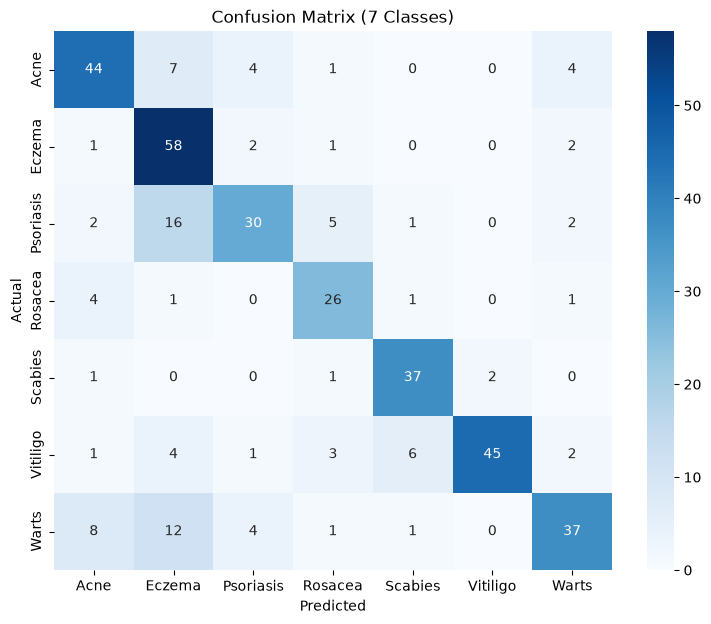


Model saved at: C:\Users\Administrator\Desktop\Skin-Disease-Detector\archive\models\skin_detector_final_7disease.keras
Final class order: ['Acne', 'Eczema', 'Psoriasis', 'Rosacea', 'Scabies', 'Vitiligo', 'Warts']


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

# ================= PATHS (same structure as your existing project) =================
BASE_DIR = r"C:\Users\Administrator\Desktop\Skin-Disease-Detector\archive"
DATASET_DIR = os.path.join(BASE_DIR, "dataset")
MODEL_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "val")
TEST_DIR = os.path.join(DATASET_DIR, "test")

IMG_SIZE = 224
BATCH = 16

# ================= DATA GENERATORS =================
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True
)
val_test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH, class_mode="categorical"
)
val_data = val_test_gen.flow_from_directory(
    VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH, class_mode="categorical"
)
test_data = val_test_gen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH, class_mode="categorical", shuffle=False
)

# This will now automatically be 7 (since Scabies folder was added)
NUM_CLASSES = train_data.num_classes
print("Classes found:", train_data.class_indices)
print("NUM_CLASSES =", NUM_CLASSES)

# ================= BUILD MODEL (same architecture as before) =================
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # freeze backbone first (same as your original approach)

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

# ================= CALLBACKS =================
checkpoint_path = os.path.join(MODEL_DIR, "skin_detector_best_7disease.keras")

checkpoint = ModelCheckpoint(
    checkpoint_path, monitor="val_accuracy",
    save_best_only=True, verbose=1
)
early_stop = EarlyStopping(
    monitor="val_loss", patience=5,
    restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.3,
    patience=3, min_lr=1e-6, verbose=1
)

# ================= PHASE 1: TRAIN WITH FROZEN BASE =================
EPOCHS = 25

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

# ================= PHASE 2: FINE-TUNE (unfreeze top layers) =================
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Class weights help if Scabies has fewer images than other classes
y_train = train_data.classes
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(weights))
print("Class weights:", class_weights)

history_ft = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[checkpoint, early_stop, reduce_lr],
    class_weight=class_weights
)

# ================= EVALUATE =================
test_loss, test_acc = model.evaluate(test_data)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

y_true = test_data.classes
y_pred = np.argmax(model.predict(test_data), axis=1)
class_names = list(test_data.class_indices.keys())

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (7 Classes)")
plt.show()

# ================= SAVE FINAL MODEL =================
FINAL_MODEL_PATH = os.path.join(MODEL_DIR, "skin_detector_final_7disease.keras")
model.save(FINAL_MODEL_PATH)
print("\nModel saved at:", FINAL_MODEL_PATH)
print("Final class order:", class_names)

Found 1350 images belonging to 7 classes.
Found 370 images belonging to 7 classes.
Found 379 images belonging to 7 classes.
Classes found: {'Acne': 0, 'Eczema': 1, 'Psoriasis': 2, 'Rosacea': 3, 'Scabies': 4, 'Vitiligo': 5, 'Warts': 6}
NUM_CLASSES = 7


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 7)                   │           1,799 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,587,719 (9.87 MB)

 Trainable params: 329,735 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.2719 - loss: 1.9698
Epoch 1: val_accuracy improved from None to 0.50541, saving model to C:\Users\Administrator\Desktop\Skin-Disease-Detector\archive\models\skin_detector_best_7disease.keras

Epoch 1: finished saving model to C:\Users\Administrator\Desktop\Skin-Disease-Detector\archive\models\skin_detector_best_7disease.keras
85/85 ━━━━━━━━━━━━━━━━━━━━ 46s 493ms/step - accuracy: 0.2719 - loss: 1.9698 - val_accuracy: 0.5054 - val_loss: 1.4135 - learning_rate: 1.0000e-04
Epoch 2/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.4556 - loss: 1.4892
Epoch 2: val_accuracy improved from 0.50541 to 0.61622, saving model to C:\Users\Administrator\Desktop\Skin-Disease-Detector\archive\models\skin_detector_best_7disease.keras

Epoch 2: finished saving model to C:\Users\Administrator\Desktop\Skin-Disease-Detector\archive\models\skin_detector_best_7disease.keras
85/85 ━━━━━━━━━━━━━━━━━━━━ 41s 477ms/step - accuracy: 0.4556 - 

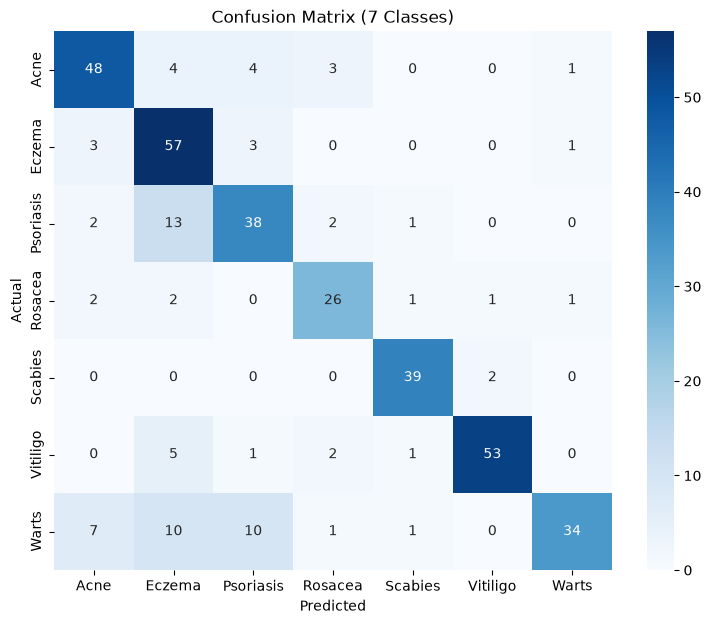


Model saved at: C:\Users\Administrator\Desktop\Skin-Disease-Detector\archive\models\skin_detector_final_7disease.keras
Final class order: ['Acne', 'Eczema', 'Psoriasis', 'Rosacea', 'Scabies', 'Vitiligo', 'Warts']


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

# ================= PATHS (same structure as your existing project) =================
BASE_DIR = r"C:\Users\Administrator\Desktop\Skin-Disease-Detector\archive"
DATASET_DIR = os.path.join(BASE_DIR, "dataset")
MODEL_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "val")
TEST_DIR = os.path.join(DATASET_DIR, "test")

IMG_SIZE = 224
BATCH = 16

# ================= DATA GENERATORS =================
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.12,
    brightness_range=[0.9, 1.1],
    horizontal_flip=True
)
val_test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH, class_mode="categorical"
)
val_data = val_test_gen.flow_from_directory(
    VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH, class_mode="categorical"
)
test_data = val_test_gen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH, class_mode="categorical", shuffle=False
)

# This will now automatically be 7 (since Scabies folder was added)
NUM_CLASSES = train_data.num_classes
print("Classes found:", train_data.class_indices)
print("NUM_CLASSES =", NUM_CLASSES)

# ================= BUILD MODEL (same architecture as before) =================
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # freeze backbone first (same as your original approach)

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

# ================= CALLBACKS =================
checkpoint_path = os.path.join(MODEL_DIR, "skin_detector_best_7disease.keras")

checkpoint = ModelCheckpoint(
    checkpoint_path, monitor="val_accuracy",
    save_best_only=True, verbose=1
)
early_stop = EarlyStopping(
    monitor="val_loss", patience=8,
    restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.3,
    patience=3, min_lr=1e-6, verbose=1
)

# ================= PHASE 1: TRAIN WITH FROZEN BASE =================
EPOCHS = 25

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

# ================= PHASE 2: FINE-TUNE (unfreeze top layers) =================
base_model.trainable = True
for layer in base_model.layers[:-15]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Class weights help if Scabies has fewer images than other classes
y_train = train_data.classes
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(weights))
print("Class weights:", class_weights)

history_ft = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[checkpoint, early_stop, reduce_lr],
    class_weight=class_weights
)

# ================= EVALUATE =================
test_loss, test_acc = model.evaluate(test_data)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

y_true = test_data.classes
y_pred = np.argmax(model.predict(test_data), axis=1)
class_names = list(test_data.class_indices.keys())

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (7 Classes)")
plt.show()

# ================= SAVE FINAL MODEL =================
FINAL_MODEL_PATH = os.path.join(MODEL_DIR, "skin_detector_final_7disease.keras")
model.save(FINAL_MODEL_PATH)
print("\nModel saved at:", FINAL_MODEL_PATH)
print("Final class order:", class_names)

Found 1350 images belonging to 7 classes.
Found 370 images belonging to 7 classes.
Found 379 images belonging to 7 classes.
Classes found: {'Acne': 0, 'Eczema': 1, 'Psoriasis': 2, 'Rosacea': 3, 'Scabies': 4, 'Vitiligo': 5, 'Warts': 6}
NUM_CLASSES = 7


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 7)                   │           1,799 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,587,719 (9.87 MB)

 Trainable params: 329,735 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 637ms/step - accuracy: 0.2822 - loss: 1.9280
Epoch 1: val_accuracy improved from None to 0.49189, saving model to C:\Users\Administrator\Desktop\Skin-Disease-Detector\archive\models\skin_detector_best_7disease_v2.keras

Epoch 1: finished saving model to C:\Users\Administrator\Desktop\Skin-Disease-Detector\archive\models\skin_detector_best_7disease_v2.keras
85/85 ━━━━━━━━━━━━━━━━━━━━ 70s 765ms/step - accuracy: 0.2822 - loss: 1.9280 - val_accuracy: 0.4919 - val_loss: 1.4151 - learning_rate: 1.0000e-04
Epoch 2/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.4570 - loss: 1.4594
Epoch 2: val_accuracy improved from 0.49189 to 0.60541, saving model to C:\Users\Administrator\Desktop\Skin-Disease-Detector\archive\models\skin_detector_best_7disease_v2.keras

Epoch 2: finished saving model to C:\Users\Administrator\Desktop\Skin-Disease-Detector\archive\models\skin_detector_best_7disease_v2.keras
85/85 ━━━━━━━━━━━━━━━━━━━━ 42s 493ms/step - accurac

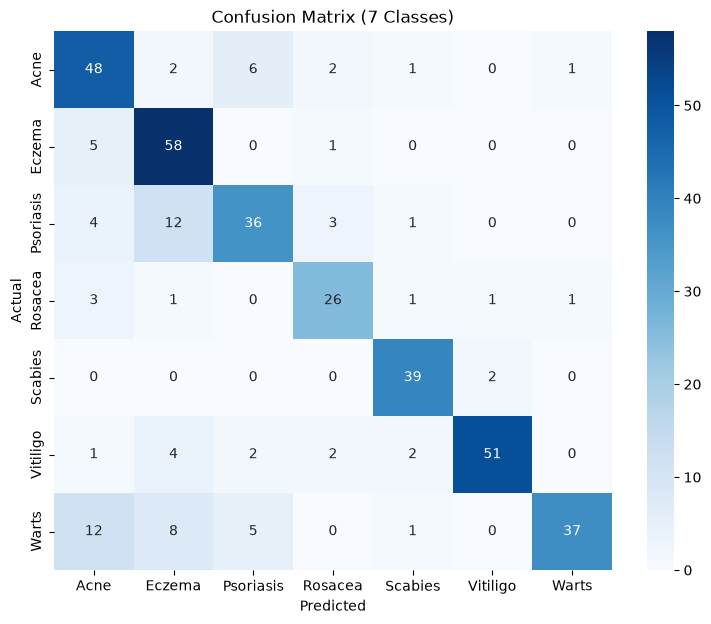


Model saved at: C:\Users\Administrator\Desktop\Skin-Disease-Detector\archive\models\skin_detector_final_7disease_v2.keras
Final class order: ['Acne', 'Eczema', 'Psoriasis', 'Rosacea', 'Scabies', 'Vitiligo', 'Warts']


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

# ================= PATHS (same structure as your existing project) =================
BASE_DIR = r"C:\Users\Administrator\Desktop\Skin-Disease-Detector\archive"
DATASET_DIR = os.path.join(BASE_DIR, "dataset")
MODEL_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "val")
TEST_DIR = os.path.join(DATASET_DIR, "test")

IMG_SIZE = 224
BATCH = 16

# ================= DATA GENERATORS =================
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.12,
    brightness_range=[0.9, 1.1],
    horizontal_flip=True
)
val_test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH, class_mode="categorical"
)
val_data = val_test_gen.flow_from_directory(
    VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH, class_mode="categorical"
)
test_data = val_test_gen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH, class_mode="categorical", shuffle=False
)

# This will now automatically be 7 (since Scabies folder was added)
NUM_CLASSES = train_data.num_classes
print("Classes found:", train_data.class_indices)
print("NUM_CLASSES =", NUM_CLASSES)

# ================= BUILD MODEL (same architecture as before) =================
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # freeze backbone first (same as your original approach)

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

# ================= CALLBACKS =================
checkpoint_path = os.path.join(MODEL_DIR, "skin_detector_best_7disease_v2.keras")

checkpoint = ModelCheckpoint(
    checkpoint_path, monitor="val_accuracy",
    save_best_only=True, verbose=1
)
early_stop = EarlyStopping(
    monitor="val_loss", patience=8,
    restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.3,
    patience=3, min_lr=1e-6, verbose=1
)

# ================= PHASE 1: TRAIN WITH FROZEN BASE =================
EPOCHS = 25

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

# ================= PHASE 2: FINE-TUNE (unfreeze top layers) =================
base_model.trainable = True
for layer in base_model.layers[:-15]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Class weights help if Scabies has fewer images than other classes
y_train = train_data.classes
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(weights))
print("Class weights:", class_weights)

history_ft = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[checkpoint, early_stop, reduce_lr],
    class_weight=class_weights
)

# ================= EVALUATE =================
test_loss, test_acc = model.evaluate(test_data)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

y_true = test_data.classes
y_pred = np.argmax(model.predict(test_data), axis=1)
class_names = list(test_data.class_indices.keys())

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (7 Classes)")
plt.show()

# ================= SAVE FINAL MODEL =================
FINAL_MODEL_PATH = os.path.join(MODEL_DIR, "skin_detector_final_7disease_v2.keras")
model.save(FINAL_MODEL_PATH)
print("\nModel saved at:", FINAL_MODEL_PATH)
print("Final class order:", class_names)